# Aritificial Neural Network (ANN) 
**Problem Statement:**
Build an ANN model to predict an employee's salary based on their experience, age, and performance.

**Input Features:**

🧑‍💼 Experience – Years of work experience

🎂 Age – Employee's age

⭐ Performance – Employee performance score

**Target Variable:**

💰 Salary

**ML Type:** Supervised Learning

**Problem Type:** Regression

**Algorithm:** Artificial Neural Network (ANN)

In [1]:
#Import Libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [2]:
# Random Dataset Creation
np.random.seed(42)

experience = np.random.randint(1, 15, 1000)
age = np.random.randint(21, 50, 1000)
performance = np.random.randint(50, 100, 1000)

# Salary Calculation
salary = (
    experience * 10000 +
    age * 500 +
    performance * 800 +
    np.random.randint(-5000, 5000, 1000)
)

In [3]:
# Convert Data into DataFrame
df = pd.DataFrame({
    "Experience": experience,
    "Age": age,
    "Performance": performance,
    "Salary": salary
})

print(df.head())

   Experience  Age  Performance  Salary
0           7   39           83  160856
1           4   37           61  108440
2          13   25           91  214016
3          11   49           58  180381
4           8   24           64  146098


In [4]:
# Selecting features as input and target as output variables
X = df[["Experience", "Age", "Performance"]]

y = df["Salary"]

In [5]:
# Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Feature Scaling (Standardization)\
# Z_Score = (X-mean) / std -> mean 0, std 1
feature_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(X_train)
X_test = feature_scaler.transform(X_test)

In [7]:
# Min-max Scaling (Normalization)
# Scaled = (x-min) / (max - min) -> fixed range like [0,1]
target_scaler = MinMaxScaler()

y_train = target_scaler.fit_transform(y_train.values.reshape(-1, 1))

y_test = target_scaler.transform(y_test.values.reshape(-1, 1))

In [8]:
# Build ANN Model
model = Sequential([

    # Input layer with 3 nodes
    Input(shape=(3,)),

    # Hidden layer 1 with 16 nodes
    Dense(16,activation='relu'),

    # Hidden layer 2 with 8 nodes
    Dense(8,activation='relu'),

    # Output layer with 1 node
    Dense(1)

])

In [9]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3122 - mae: 0.4512 - val_loss: 0.2099 - val_mae: 0.3772
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1334 - mae: 0.2947 - val_loss: 0.0917 - val_mae: 0.2473
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0556 - mae: 0.1923 - val_loss: 0.0379 - val_mae: 0.1578
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0249 - mae: 0.1281 - val_loss: 0.0190 - val_mae: 0.1111
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0155 - mae: 0.0993 - val_loss: 0.0135 - val_mae: 0.0934
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0128 - mae: 0.0909 - val_loss: 0.0115 - val_mae: 0.0863
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0114 - mae: 0.0864 - val_loss: 0.0103 - val_mae: 0.0814
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0102 - mae: 0.0821 - val_loss: 0.0093 - val_mae: 0.0773
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [22]:
# Evaluate the model
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("\nLoss :", loss)
print("MAE  :", mae)

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict test salaries
y_pred = model.predict(X_test)

# Convert scaled values back to actual salary
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test)

# Calculate MSE and MAE in actual salary values
mse = mean_squared_error(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("\nMSE :", round(mse, 2))
print("MAE : ₹", round(mae, 2))
print("The ANN model has an average salary prediction error of approximately ₹",round(mae, 2)," on the test data.")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8427e-04 - mae: 0.0197

Loss : 0.0005842697573825717
MAE  : 0.01967066526412964
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

MSE : 19628026.05
MAE : ₹ 3605.38
The ANN model has an average salary prediction error of approximately ₹ 3605.38  on the test data.


In [23]:
# Predict New Employee Salary

new_employee = pd.DataFrame({
    "Experience": [7],
    "Age": [30],
    "Performance": [88]
})

new_employee_scaled = feature_scaler.transform(new_employee)

salary_prediction = model.predict(new_employee_scaled)

# Convert back to actual salary
salary_prediction = target_scaler.inverse_transform(salary_prediction)

print("\nPredicted Salary : ₹",round(salary_prediction[0][0], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Predicted Salary : ₹ 157205.3


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


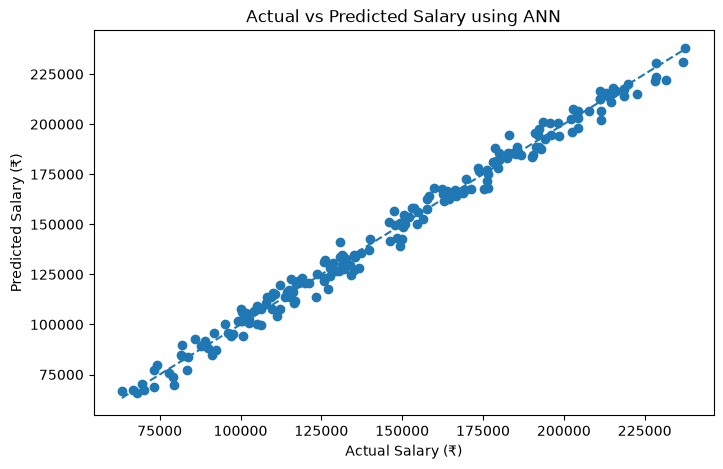

In [24]:
# Data visualization - Actual Salary Vs Predicted Salary
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)

# Convert scaled values back to actual salary
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_actual,
    y_pred_actual
)

# Perfect prediction line
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    linestyle="--"
)

plt.xlabel("Actual Salary (₹)")
plt.ylabel("Predicted Salary (₹)")
plt.title("Actual vs Predicted Salary using ANN")

plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
New Employee Details
Experience  : 7 years
Age         : 30
Performance : 88
Predicted Salary : ₹ 157205.3


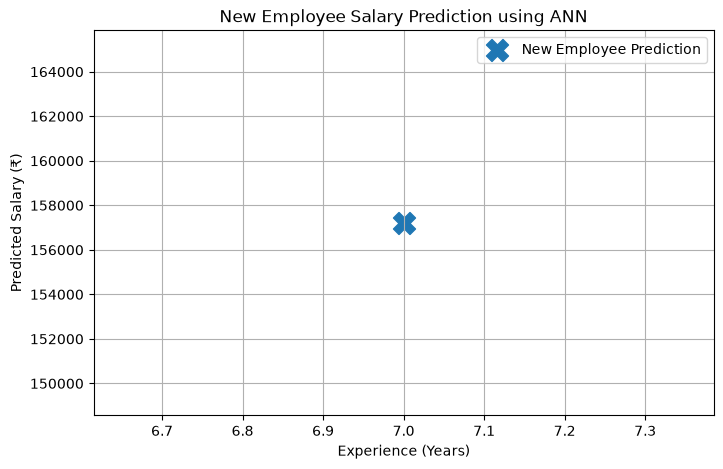

In [25]:
# New employee
new_employee = pd.DataFrame(
    [[7, 30, 88]],
    columns=["Experience", "Age", "Performance"]
)

# Scale input
new_employee_scaled = feature_scaler.transform(new_employee)

# Predict salary
new_salary = model.predict(new_employee_scaled)

# Convert prediction back to actual salary
new_salary_actual = target_scaler.inverse_transform(new_salary)

print("New Employee Details")
print("Experience  :", new_employee.iloc[0]["Experience"], "years")
print("Age         :", new_employee.iloc[0]["Age"])
print("Performance :", new_employee.iloc[0]["Performance"])
print("Predicted Salary : ₹", round(new_salary_actual[0][0], 2))

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    new_employee.iloc[0]["Experience"],
    new_salary_actual[0][0],
    marker="X",
    s=250,
    label="New Employee Prediction"
)

plt.xlabel("Experience (Years)")
plt.ylabel("Predicted Salary (₹)")
plt.title("New Employee Salary Prediction using ANN")

plt.legend()
plt.grid(True)
plt.show()

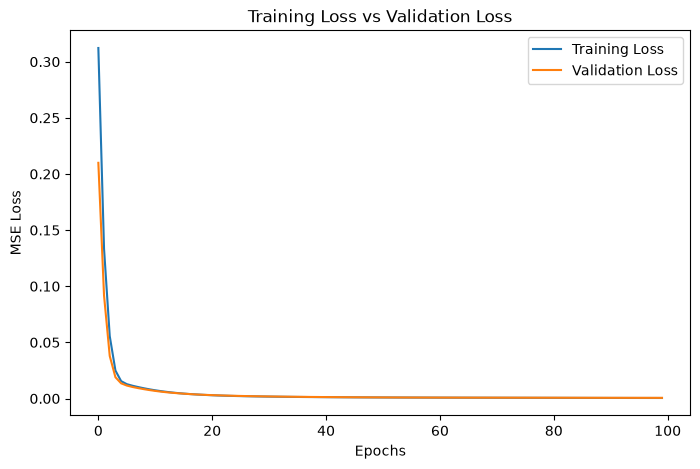

In [26]:
# Training Loss vs Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss vs Validation Loss")

plt.legend()
plt.show()